In [23]:
import nbformat
from google.colab import files

nb_path = "/content/drive/MyDrive/Colab Notebooks/MS4_YOLO.ipynb"   # change to your notebook name

nb = nbformat.read(nb_path, as_version=4)

# 🔥 Remove widget metadata ONLY
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, nb_path)

print("✅ Cleaned notebook (outputs preserved)")

files.download(nb_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/MS4_YOLO.ipynb'

# YOLO Fine-Tuning for Hair Follicle Detection

**Main changes:**

- YOLO requires labels in normalized YOLO format: `class cx cy w h`.
- Training uses `ultralytics.YOLO` instead of Hugging Face `Trainer`.
- YOLO applies its own object-detection losses internally
- Augmentation: Ultralytics applies built-in augmentation

In [3]:

# Install dependencies
!pip -q install ultralytics albumentations opencv-python scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00


In [4]:

import os
import shutil
import random
import yaml
import json
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

import torch
from torchvision.ops import box_iou

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# dataset from Drive to Colab runtime
!cp -r /content/drive/MyDrive/data /content/

## Config

In [7]:
#  CONFIG
@dataclass
class Config:
    # Original Pascal VOC dataset paths
    image_dir: str = "/content/data/Images"
    annot_dir: str = "/content/data/Annotations"
    split_dir: str = "/content/data/ImageSets/Main"

    # YOLO converted dataset output
    yolo_root: str = "/content/yolo_follicle_dataset"

    # YOLO model: yolov8n.pt, yolov8s.pt, yolov11n.pt, yolov11s.pt
    pretrained_model_name: str = "yolo11m.pt"

    # classes
    class_names: Optional[List[str]] = None

    # training
    image_size: int = 800
    epochs: int = 100
    batch: int = 8
    workers: int = 2
    lr0: float = 1e-3
    patience: int = 30
    seed: int = 42

    # evaluation / prediction
    conf_threshold: float = 0.25
    iou_threshold: float = 0.50

cfg = Config()

if cfg.class_names is None:
    # define class
    cfg.class_names = ["premium", "single", "undersize", "abnormal"]

label2id = {name: i for i, name in enumerate(cfg.class_names)}
id2label = {i: name for name, i in label2id.items()}

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

print(label2id)

{'premium': 0, 'single': 1, 'undersize': 2, 'abnormal': 3}


## Load train/validation split

In [8]:
# Load training and validation file names
def read_split_txt(path: str) -> List[str]:
    with open(path) as f:
        return [line.strip() for line in f.readlines() if line.strip()]

train_files = read_split_txt(os.path.join(cfg.split_dir, "train.txt"))
val_files = read_split_txt(os.path.join(cfg.split_dir, "val.txt"))

print("train:", len(train_files))
print("val:", len(val_files))
print("example train file stem:", train_files[0] if train_files else None)

train: 992
val: 330
example train file stem: 220106_A207_2


## XML parser and box utilities

In [9]:
#  Pascal VOC XML parser and bbox utilities
def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]

def is_valid_xyxy(box):
    x1, y1, x2, y2 = box
    return np.isfinite(box).all() and (x2 > x1) and (y2 > y1)

def xyxy_to_yolo(box, width, height):
    """Convert absolute xyxy box to normalized YOLO cx cy w h."""
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2.0) / width
    cy = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return [cx, cy, bw, bh]

def yolo_to_xyxy(box, width, height):
    """Convert normalized YOLO cx cy w h to absolute xyxy."""
    cx, cy, bw, bh = box
    cx *= width
    cy *= height
    bw *= width
    bh *= height
    return [cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2]

def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")

    width = int(size.findtext("width")) if size is not None and size.findtext("width") else None
    height = int(size.findtext("height")) if size is not None and size.findtext("height") else None

    objects = []
    for obj in root.findall("object"):
        # Some VOC-like datasets use <class>; standard VOC uses <name>
        label_name = obj.findtext("name") or obj.findtext("class")
        if label_name is None:
            continue
        label_name = label_name.strip()
        if label_name not in label2id:
            print(f"Skipping unknown class {label_name} in {xml_path}")
            continue

        bnd = obj.find("bndbox")
        if bnd is None:
            continue

        x1 = float(bnd.findtext("xmin"))
        y1 = float(bnd.findtext("ymin"))
        x2 = float(bnd.findtext("xmax"))
        y2 = float(bnd.findtext("ymax"))

        # Fix inverted coordinates if present
        x1, x2 = sorted([x1, x2])
        y1, y2 = sorted([y1, y2])

        if width is not None and height is not None:
            box = clip_box_xyxy([x1, y1, x2, y2], width, height)
        else:
            box = [x1, y1, x2, y2]

        if not is_valid_xyxy(np.array(box, dtype=float)):
            continue

        objects.append({
            "class_name": label_name,
            "class_id": label2id[label_name],
            "bbox_xyxy": box,
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }

## Convert Pascal VOC annotations to YOLO format

In [10]:
#  Convert VOC dataset into YOLO directory structure
def find_image_path(image_dir: str, stem: str) -> Optional[str]:
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        p = os.path.join(image_dir, stem + ext)
        if os.path.exists(p):
            return p
    return None

def reset_dir(path: str):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def convert_split_to_yolo(split_name: str, stems: List[str], cfg: Config):
    img_out = os.path.join(cfg.yolo_root, "images", split_name)
    lab_out = os.path.join(cfg.yolo_root, "labels", split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lab_out, exist_ok=True)

    skipped = []
    class_counter = Counter()
    box_counter = 0

    for stem in stems:
        xml_path = os.path.join(cfg.annot_dir, stem + ".xml")
        img_path = find_image_path(cfg.image_dir, stem)

        if not os.path.exists(xml_path) or img_path is None:
            skipped.append(stem)
            continue

        parsed = parse_voc_xml(xml_path, label2id)
        image = Image.open(img_path).convert("RGB")
        W, H = image.size

        # Copy image
        out_img_path = os.path.join(img_out, os.path.basename(img_path))
        shutil.copy2(img_path, out_img_path)

        # Write YOLO label file
        out_label_path = os.path.join(lab_out, stem + ".txt")
        lines = []
        for obj in parsed["objects"]:
            box = clip_box_xyxy(obj["bbox_xyxy"], W, H)
            if not is_valid_xyxy(np.array(box, dtype=float)):
                continue
            cx, cy, bw, bh = xyxy_to_yolo(box, W, H)
            # Extra check against numerical problems
            cx, cy, bw, bh = [min(max(v, 0.0), 1.0) for v in [cx, cy, bw, bh]]
            if bw <= 0 or bh <= 0:
                continue
            cls_id = obj["class_id"]
            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
            class_counter[cls_id] += 1
            box_counter += 1

        with open(out_label_path, "w") as f:
            f.write("\n".join(lines))

    return {
        "split": split_name,
        "images": len(stems) - len(skipped),
        "skipped": skipped,
        "boxes": box_counter,
        "class_counter": dict(class_counter),
    }

reset_dir(cfg.yolo_root)
train_stats = convert_split_to_yolo("train", train_files, cfg)
val_stats = convert_split_to_yolo("val", val_files, cfg)

print(train_stats)
print(val_stats)

{'split': 'train', 'images': 992, 'skipped': [], 'boxes': 12224, 'class_counter': {0: 8065, 2: 917, 1: 2820, 3: 422}}
{'split': 'val', 'images': 330, 'skipped': [], 'boxes': 4227, 'class_counter': {3: 153, 0: 2884, 1: 942, 2: 248}}


In [11]:
# Create YOLO data.yaml

data_yaml = {
    "path": cfg.yolo_root,
    "train": "images/train",
    "val": "images/val",
    "names": id2label,
}

yaml_path = os.path.join(cfg.yolo_root, "data.yaml")
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(yaml_path)
print(open(yaml_path).read())

/content/yolo_follicle_dataset/data.yaml
path: /content/yolo_follicle_dataset
train: images/train
val: images/val
names:
  0: premium
  1: single
  2: undersize
  3: abnormal



## Quick dataset sanity check

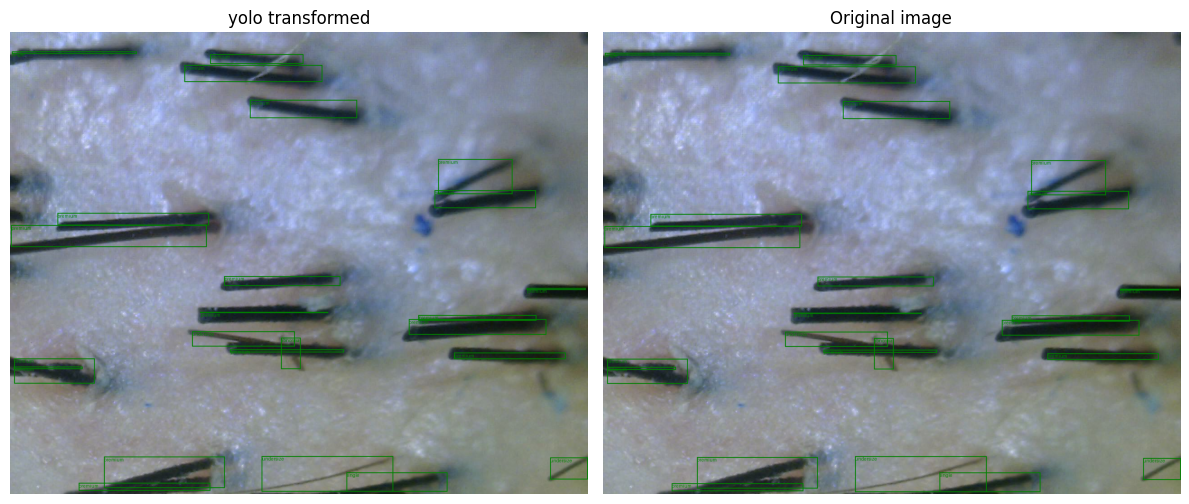

In [13]:
#  Draw YOLO labels over one converted image

def draw_yolo_label_file(image_path, label_path, id2label, color="green"):
    image = Image.open(image_path).convert("RGB")
    W, H = image.size
    draw = ImageDraw.Draw(image)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(parts[0])
                box = list(map(float, parts[1:]))
                x1, y1, x2, y2 = yolo_to_xyxy(box, W, H)
                draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
                draw.text((x1, y1), id2label[cls], fill=color)
    return image

sample_stem = train_files[0]
sample_img = find_image_path(os.path.join(cfg.yolo_root, "images", "train"), sample_stem)
sample_lab = os.path.join(cfg.yolo_root, "labels", "train", sample_stem + ".txt")

img_yolo = draw_yolo_label_file(sample_img, sample_lab, id2label)

## Original:
xml_path = '/content/data/Annotations/220106_A207_2.xml'
image_path = "/content/data/Images/220106_A207_2.jpg"
parsed = parse_voc_xml(xml_path, label2id)
image_orig = Image.open(image_path).convert("RGB")
gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [id2label[obj["class_id"]] for obj in parsed["objects"]]
draw = ImageDraw.Draw(image_orig)
for box, label in zip(gt_boxes, gt_labels):
    x1, y1, x2, y2 = box
    draw.rectangle([x1, y1, x2, y2], outline='green', width=2)
    draw.text((x1, y1), label, fill='green')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_yolo)
plt.title('yolo transformed')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_orig)
plt.title('Original image')
plt.axis("off")

plt.tight_layout()
plt.show()

## Train YOLO

In [16]:

drive_dir ='/content/drive/MyDrive/yolo_follicle'
run_name = "follicle_yolo_cleanloc_11m"
run_dir = os.path.join(drive_dir, run_name)
best_path = os.path.join(run_dir, "weights", "best.pt")

os.makedirs(run_dir, exist_ok=True)

# Train if model doesn't exists
if os.path.exists(best_path):
    print("Model already trained. Loading from Drive...")
    model = YOLO(best_path)


else:
    print("Training model...")

    model = YOLO(cfg.pretrained_model_name)

    results = model.train(
    data=yaml_path,
    imgsz=1024,
    epochs=100,
    batch=cfg.batch,

    box=9.0,
    dfl=2.0,
    cls=1.2,

    optimizer="AdamW",
    lr0=0.0003,
    weight_decay=0.0005,

    mosaic=0.1,
    close_mosaic=20,
    degrees=2.0,
    perspective=0.0,
    shear=0.0,
    scale=0.15,
    translate=0.03,
    flipud=0.2,
    fliplr=0.5,

    patience=30,
    seed=cfg.seed,
    project=drive_dir,
    name=run_name,
    exist_ok=True,
)


    print("Training complete. Loading best model...")
    model = YOLO(best_path)

Model already trained. Loading from Drive...


## Load best model and validate

In [17]:
#Load best YOLO checkpoint and run built-in validation

if os.path.exists(best_path):
    yolo_model = YOLO(best_path)
else:
    print("Best checkpoint not found; using current model object.")
    yolo_model = model

val_results = yolo_model.val(
    data=yaml_path,
    imgsz=cfg.image_size,
    conf=cfg.conf_threshold,
    iou=cfg.iou_threshold,
)

print(val_results)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1834.2±550.0 MB/s, size: 103.3 KB)
val: Scanning /content/yolo_follicle_dataset/labels/val... 330 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 2.2Kit/s 0.1s
val: New cache created: /content/yolo_follicle_dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.3it/s 16.2s
                   all        330       4227       0.68      0.616      0.532      0.331
               premium        330       2884       0.86      0.702      0.671       0.42
                single        307        942      0.751      0.811      0.741      0.503
             undersize        161        248      0.548      0.617      0.455      0.259
              abnormal        103        153       0.5

## Plot training curves

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
54,55,5800.67,1.29386,1.36831,1.42591,0.70194,0.60828,0.61659,0.36971,1.56216,2.01554,1.59072,0.000140,0.000140,0.000140
55,56,5903.40,1.28853,1.33946,1.42381,0.66563,0.60124,0.59731,0.35475,1.56883,2.06818,1.60488,0.000137,0.000137,0.000137
56,57,6009.84,1.29315,1.36678,1.42977,0.65231,0.62592,0.62645,0.37739,1.58178,2.04043,1.60978,0.000134,0.000134,0.000134
57,58,6111.83,1.29133,1.35072,1.42889,0.66359,0.64554,0.62940,0.36976,1.59207,2.07301,1.61856,0.000131,0.000131,0.000131
58,59,6218.22,1.27304,1.32336,1.41877,0.69703,0.61849,0.62163,0.37105,1.57139,2.01768,1.59887,0.000128,0.000128,0.000128


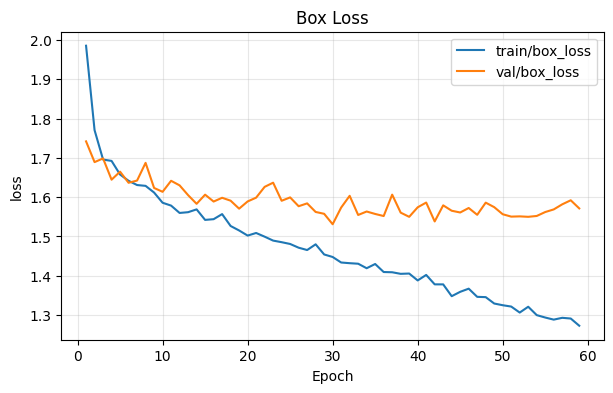

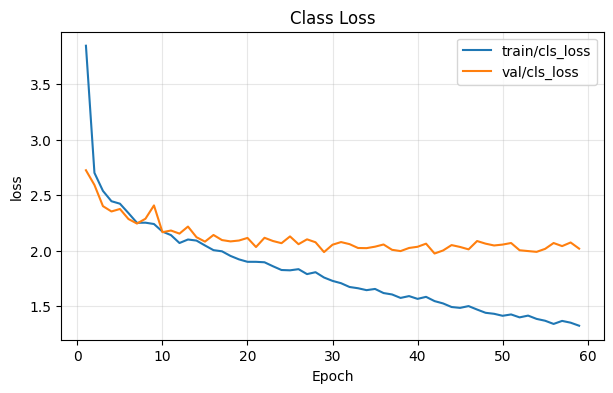

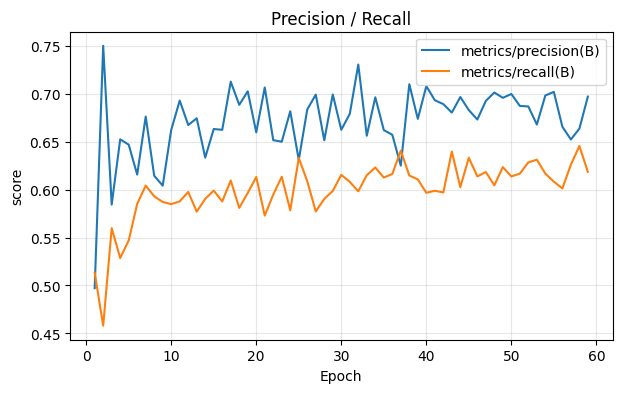

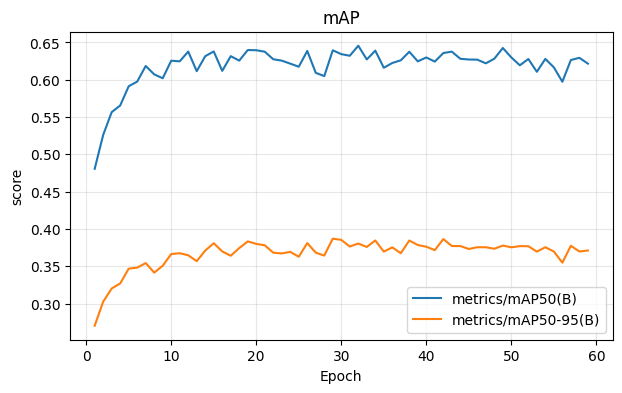

In [19]:
#  Plot YOLO training logs
results_csv = f"{run_dir}/results.csv"

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    display(df.tail())

    for cols, title, ylabel in [
        (["train/box_loss", "val/box_loss"], "Box Loss", "loss"),
        (["train/cls_loss", "val/cls_loss"], "Class Loss", "loss"),
        (["metrics/precision(B)", "metrics/recall(B)"], "Precision / Recall", "score"),
        (["metrics/mAP50(B)", "metrics/mAP50-95(B)"], "mAP", "score"),
    ]:
        existing = [c for c in cols if c in df.columns]
        if existing:
            plt.figure(figsize=(7, 4))
            for c in existing:
                plt.plot(df["epoch"], df[c], label=c)
            plt.title(title)
            plt.xlabel("Epoch")
            plt.ylabel(ylabel)
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
else:
    print("results.csv not found yet.")

## Hungarian matching evaluation for YOLO predictions

In [20]:
# Hungarian one-to-one evaluation for YOLO predictions

def load_gt_from_yolo_label(image_path: str, label_path: str):
    image = Image.open(image_path).convert("RGB")
    W, H = image.size
    boxes = []
    labels = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                labels.append(int(parts[0]))
                boxes.append(yolo_to_xyxy(list(map(float, parts[1:])), W, H))
    return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)


def predict_yolo_xyxy(model, image_path: str, conf=0.25, imgsz=800):
    result = model.predict(image_path, conf=conf, imgsz=imgsz, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        return (
            np.zeros((0, 4), dtype=np.float32),
            np.zeros((0,), dtype=np.int64),
            np.zeros((0,), dtype=np.float32),
        )
    boxes = result.boxes.xyxy.cpu().numpy().astype(np.float32)
    labels = result.boxes.cls.cpu().numpy().astype(np.int64)
    scores = result.boxes.conf.cpu().numpy().astype(np.float32)
    return boxes, labels, scores


def hungarian_match(pred_boxes, gt_boxes, iou_threshold=0.5):
    """Return matched prediction indices and GT indices using max-IoU Hungarian assignment."""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return []

    pb = torch.tensor(pred_boxes, dtype=torch.float32)
    gb = torch.tensor(gt_boxes, dtype=torch.float32)
    ious = box_iou(pb, gb).numpy()

    # Hungarian minimizes cost, so use negative IoU.
    pred_idx, gt_idx = linear_sum_assignment(-ious)

    matches = []
    for p, g in zip(pred_idx, gt_idx):
        if ious[p, g] >= iou_threshold:
            matches.append((p, g, float(ious[p, g])))
    return matches


def evaluate_yolo_hungarian(
    model,
    image_dir: str,
    label_dir: str,
    stems: List[str],
    id2label: Dict[int, str],
    conf_threshold=0.25,
    iou_threshold=0.5,
    imgsz=800,
):
    total_predictions = 0
    total_gt = 0
    total_matches = 0
    correct_matches = 0
    sum_matched_iou = 0.0

    y_true = []
    y_pred = []

    for stem in stems:
        image_path = find_image_path(image_dir, stem)
        label_path = os.path.join(label_dir, stem + ".txt")
        if image_path is None:
            continue

        gt_boxes, gt_labels = load_gt_from_yolo_label(image_path, label_path)
        pred_boxes, pred_labels, pred_scores = predict_yolo_xyxy(
            model, image_path, conf=conf_threshold, imgsz=imgsz
        )

        total_predictions += len(pred_boxes)
        total_gt += len(gt_boxes)

        matches = hungarian_match(pred_boxes, gt_boxes, iou_threshold=iou_threshold)
        total_matches += len(matches)

        for p, g, iou in matches:
            sum_matched_iou += iou
            y_true.append(int(gt_labels[g]))
            y_pred.append(int(pred_labels[p]))
            if int(pred_labels[p]) == int(gt_labels[g]):
                correct_matches += 1

    detection_recall = total_matches / total_gt if total_gt else 0.0
    detection_precision = total_matches / total_predictions if total_predictions else 0.0
    matched_class_accuracy = correct_matches / total_matches if total_matches else 0.0
    mean_matched_iou = sum_matched_iou / total_matches if total_matches else 0.0

    if y_true:
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
        cm = confusion_matrix(y_true, y_pred, labels=list(id2label.keys()))
    else:
        macro_f1 = micro_f1 = 0.0
        cm = np.zeros((len(id2label), len(id2label)), dtype=int)

    metrics = {
        "total_gt": total_gt,
        "total_predictions": total_predictions,
        "matched_boxes": total_matches,
        "detection_precision": detection_precision,
        "detection_recall": detection_recall,
        "matched_class_accuracy": matched_class_accuracy,
        "mean_matched_iou": mean_matched_iou,
        "macro_f1_on_matched": macro_f1,
        "micro_f1_on_matched": micro_f1,
    }

    return metrics, cm

metrics, cm = evaluate_yolo_hungarian(
    yolo_model,
    image_dir=os.path.join(cfg.yolo_root, "images", "val"),
    label_dir=os.path.join(cfg.yolo_root, "labels", "val"),
    stems=val_files,
    id2label=id2label,
    conf_threshold=cfg.conf_threshold,
    iou_threshold=cfg.iou_threshold,
    imgsz=cfg.image_size,
)

print(json.dumps(metrics, indent=2))
print("Confusion matrix rows=true, cols=pred")
print(pd.DataFrame(cm, index=[id2label[i] for i in id2label], columns=[id2label[i] for i in id2label]))

{
  "total_gt": 4227,
  "total_predictions": 4192,
  "matched_boxes": 3259,
  "detection_precision": 0.7774332061068703,
  "detection_recall": 0.770995978235155,
  "matched_class_accuracy": 0.8999693157410249,
  "mean_matched_iou": 0.8118457233258353,
  "macro_f1_on_matched": 0.834934499663175,
  "micro_f1_on_matched": 0.8999693157410249
}
Confusion matrix rows=true, cols=pred
           premium  single  undersize  abnormal
premium       2015     141         41         5
single          93     723         20         4
undersize        0       1        143         7
abnormal         2       1         11        52


## Predict, match, and draw one image

,pred_idx,gt_idx,iou,gt_label,pred_label,score,class_correct
0,0,4,0.575008,premium,premium,0.804666,True
1,1,11,0.642762,premium,premium,0.791279,True
2,3,3,0.721767,premium,premium,0.763188,True
3,4,2,0.789539,premium,premium,0.663860,True
4,5,8,0.784315,single,single,0.663468,True
5,6,7,0.865566,premium,premium,0.658099,True
6,7,6,0.958853,premium,premium,0.634811,True
7,8,1,0.697428,premium,premium,0.620260,True
8,10,9,0.652951,single,undersize,0.527989,False


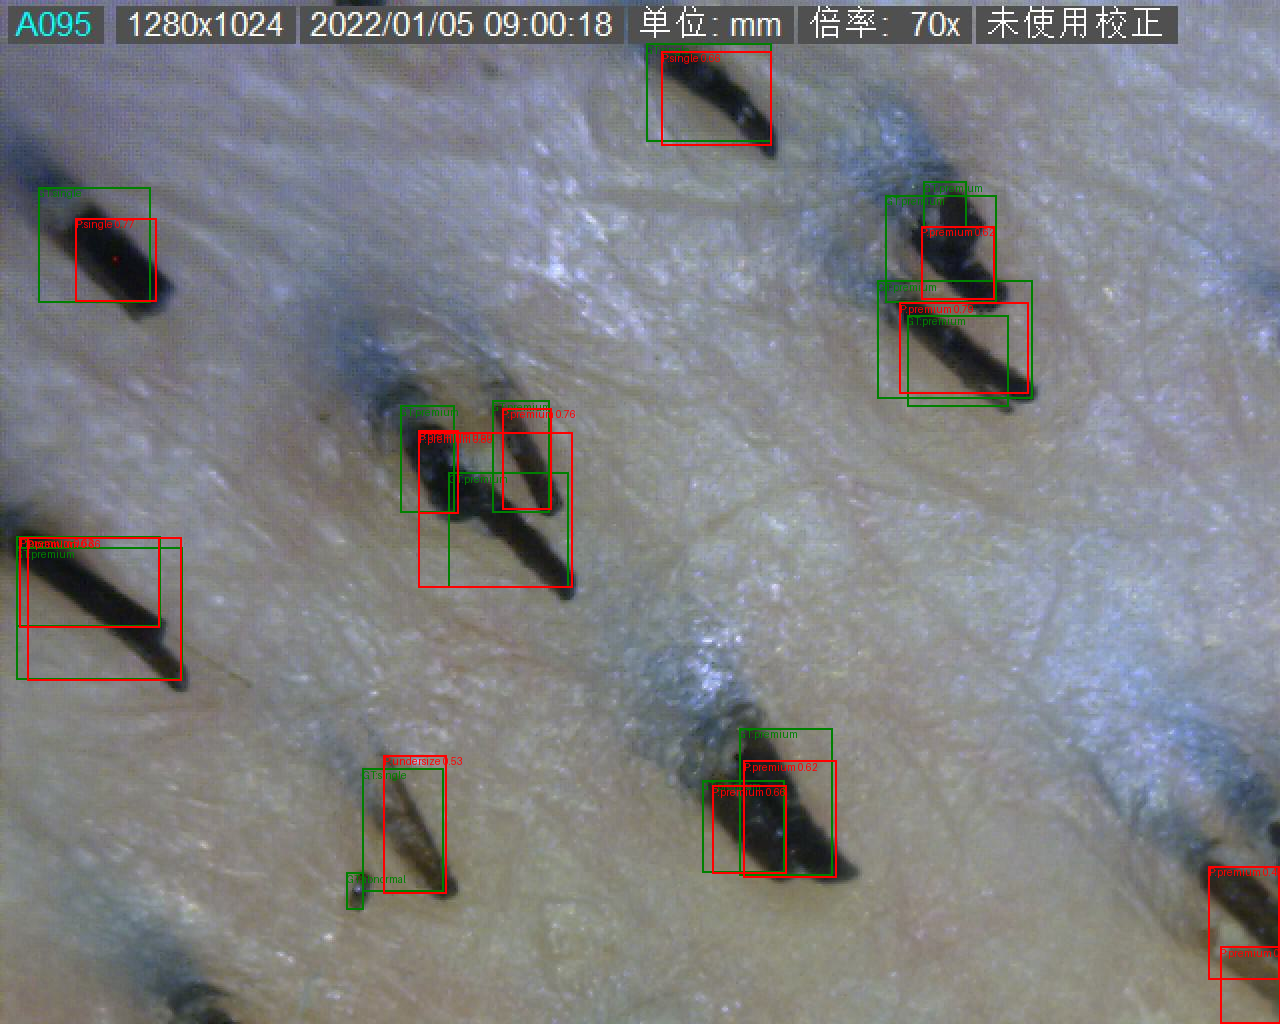

In [22]:
#  Visualization: GT + YOLO predictions + Hungarian matches

def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), str(label), fill=color)
    return image


def predict_match_and_draw_yolo(
    image_path,
    label_path,
    model,
    id2label,
    conf_threshold=0.25,
    iou_threshold=0.5,
    imgsz=800,
):
    image = Image.open(image_path).convert("RGB")

    gt_boxes, gt_labels = load_gt_from_yolo_label(image_path, label_path)
    pred_boxes, pred_labels, pred_scores = predict_yolo_xyxy(
        model, image_path, conf=conf_threshold, imgsz=imgsz
    )

    gt_text = [f"GT:{id2label[int(c)]}" for c in gt_labels]
    pred_text = [f"P:{id2label[int(c)]} {s:.2f}" for c, s in zip(pred_labels, pred_scores)]

    # GT green, predictions red
    image = draw_boxes(image, gt_boxes, gt_text, color="green", width=2)
    image = draw_boxes(image, pred_boxes, pred_text, color="red", width=2)

    matches = hungarian_match(pred_boxes, gt_boxes, iou_threshold=iou_threshold)
    match_rows = []
    for p, g, iou in matches:
        match_rows.append({
            "pred_idx": p,
            "gt_idx": g,
            "iou": iou,
            "gt_label": id2label[int(gt_labels[g])],
            "pred_label": id2label[int(pred_labels[p])],
            "score": float(pred_scores[p]),
            "class_correct": int(gt_labels[g]) == int(pred_labels[p]),
        })

    return image, pd.DataFrame(match_rows)

sample_stem = val_files[0]
image_path = find_image_path(os.path.join(cfg.yolo_root, "images", "val"), sample_stem)
label_path = os.path.join(cfg.yolo_root, "labels", "val", sample_stem + ".txt")

img, matches_df = predict_match_and_draw_yolo(
    image_path=image_path,
    label_path=label_path,
    model=yolo_model,
    id2label=id2label,
    conf_threshold=cfg.conf_threshold,
    iou_threshold=cfg.iou_threshold,
    imgsz=cfg.image_size,
)

display(matches_df)
img